In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import sys
from tqdm import tqdm
sys.path.append("../src")
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
from border_effects_kNN_del import delaunay_edges, knn_edges, rnn_edges, build_graph
from truncated_graphs import distance_to_border, compute_centrality_measures
from fit import fit_piece_wise_linear, fit_log, fit_constant, fit_exponential_saturation
from evaluate_fit import log_likelihood, relative_likelihood

In [4]:
np.random.seed(41)

In [5]:
with open("/data/bionets/je30bery/truncated_graphs/mibitof_coords/coords.pickle", "rb") as f:
    datasets = pickle.load(f)

In [6]:
delaunay_dfs = pd.read_csv("../results/delaunay_centralities.csv")    
delaunay_dfs = delaunay_dfs[delaunay_dfs["dataset"] != "glioma_mibitof:CHOP_907_R1C6_whole_cell.tiff"]

In [7]:
delaunay_dfs = delaunay_dfs.set_index(["dataset", "Unnamed: 0"])

In [8]:
dataset = "TNBC_mibitof:p14_labeledcellData.tiff"
coords = datasets[dataset]

In [9]:
G = nx.Graph()
G.add_nodes_from(range(len(coords)))
for n in G.nodes:
    G.nodes[n]["pos"] = coords[n]
G.add_edges_from(delaunay_edges(coords))

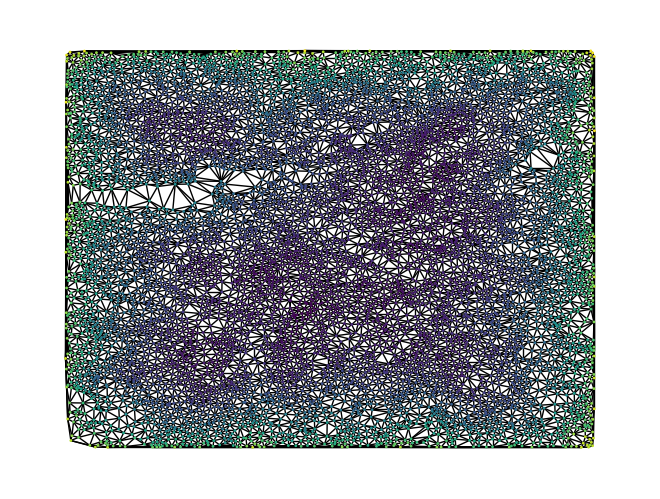

In [10]:
nx.draw(G, pos=nx.get_node_attributes(G, "pos"), node_color=delaunay_dfs.loc[dataset]["closeness"], node_size=1)

0.04087828215406523
0.049934264331588776
0.061397957782809306
0.051904300233639206


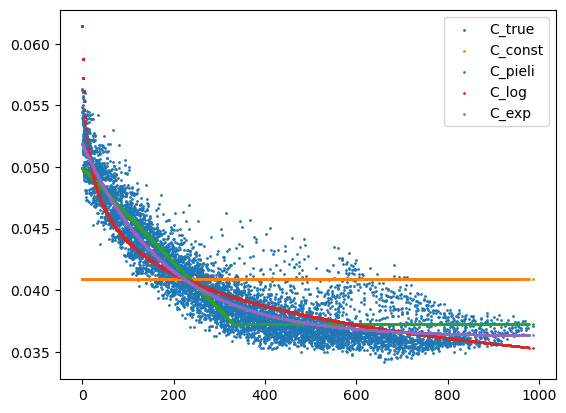

In [14]:
measure = "closeness"
dataset_df = delaunay_dfs.loc[dataset]
d = dataset_df["distance_to_border"]
C_true = dataset_df[measure].values   
a, C_const = fit_constant(C_true)       
print(a)
m, c0, b, C_pieli = fit_piece_wise_linear(d, C_true)
print(c0)
a, b, C_log = fit_log(d, C_true)
print(b)
a, b, c, C_exp = fit_exponential_saturation(d, C_true)
print(c)

plt.scatter(d, C_true, label="C_true", s=1)
plt.scatter(d, C_const, label="C_const", s=1)
plt.scatter(d, C_pieli, label="C_pieli", s=1)
plt.scatter(d, C_log, label="C_log", s=1)
plt.scatter(d, C_exp, label="C_exp", s=1)
plt.legend()

In [12]:
print(a)
print(c0)
print(b)
print(a *  + c)

-0.015636022160342627
0.049934264331588776
0.0054322141299817574
-0.0008115767886702597


In [13]:
(1 - np.exp(0))

0.0